# Project 2
## Problem 4

### Part a) Non-identifiability of the theta-logistic model

We want to show that the model specified by (1) and (2) is non identifiable, meaning that different parameter values lead to the same distribution of the observed data $\mathbf{y}$.

#### Setup

The model is:
$$u_t = u_{t-1} + r\left(1 - \left(\frac{e^{u_{t-1}}}{K}\right)^\theta\right) + e_t, \qquad e_t \sim N(0, \sigma) \tag{1}$$
$$y_t \sim \text{Poisson}(c\, e^{u_t}) \tag{2}$$

with parameters $\boldsymbol{\theta} = (r, K, \theta, \sigma, c)$ and latent states $\mathbf{u} = (u_1, \ldots, u_n)$.

#### Showing non-identifiability

Consider shifting all latent states by a constant $\delta \in \mathbb{R}$:

$$v_t = u_t + \delta$$

Substituting $u_t = v_t - \delta$ and $u_{t-1} = v_{t-1} - \delta$ into (1):

$$v_t - \delta = (v_{t-1} - \delta) + r\left(1 - \left(\frac{e^{v_{t-1} - \delta}}{K}\right)^\theta\right) + e_t$$

$$v_t = v_{t-1} + r\left(1 - \left(\frac{e^{v_{t-1}}}{K e^{\delta}}\right)^\theta\right) + e_t$$

Define $K' = K e^{\delta}$. Then:

$$v_t = v_{t-1} + r\left(1 - \left(\frac{e^{v_{t-1}}}{K'}\right)^\theta\right) + e_t$$

This has exactly the same form as the original state equation (1), but with $K$ replaced by $K' = K e^{\delta}$.

Substituting $u_t = v_t - \delta$ into (2):

$$y_t \sim \text{Poisson}(c\, e^{u_t}) = \text{Poisson}(c\, e^{v_t - \delta}) = \text{Poisson}(c\, e^{-\delta}\, e^{v_t})$$

Define $c' = c\, e^{-\delta}$. Then:

$$y_t \sim \text{Poisson}(c'\, e^{v_t})$$

This has exactly the same form as the original observation equation (2), but with $c$ replaced by $c' = c\, e^{-\delta}$.

The transformed model with parameters $(r, K', \theta, \sigma, c')$ and latent states $\mathbf{v}$ produces exactly the same distribution over observations $\mathbf{y}$ as the original model with parameters $(r, K, \theta, \sigma, c)$ and latent states $\mathbf{u}$. Since $\delta$ is arbitrary, infinitely many parameter combinations give the same likelihood. Therefore, the model is non identifiable: the parameters $c$ and $K$ cannot be estimated simultaneously.

Note that $c' \cdot K'^\theta = c\,e^{-\delta} \cdot (K\,e^{\delta})^\theta$ depends on $\delta$ unless $\theta = 1$, but the key point is that $c' \cdot (K')^0 \neq c \cdot K^0$ in general. The non-identifiability arises because a shift in the latent process can always be absorbed by jointly rescaling $c$ and $K$.

#### Making the model identifiable

To make the model identifiable without changing the model space, we fix $c = 1$. This is equivalent to absorbing the sampling effort into the latent states by redefining $u_t \leftarrow u_t + \ln c$, so that:

$$y_t \sim \text{Poisson}(e^{u_t})$$

With $c$ fixed, the shift $\delta$ is no longer a free parameter (since changing $\delta$ would require changing $c$), and $(r, K, \theta, \sigma)$ become identifiable. $\square$

### Part b) Laplace approximation with RTMB

We fix $c = 1$ for identifiability (from part a). The joint density $f(\mathbf{y}, \mathbf{u} | \boldsymbol{\theta})$ consists of:

1. **Prior on $u_1$:** $\pi(u_1) \propto 1$ (improper uniform), contributes no terms.
2. **State transitions** ($t = 2, \ldots, n$): $u_t | u_{t-1} \sim N\left(u_{t-1} + r\left(1 - \left(\frac{e^{u_{t-1}}}{K}\right)^\theta\right),\; \sigma^2\right)$
3. **Observations** ($t = 1, \ldots, n$): $y_t \sim \text{Poisson}(e^{u_t})$

The negative log joint density is therefore:

$$-\log f(\mathbf{y}, \mathbf{u} | \boldsymbol{\theta}) = -\sum_{t=2}^{n} \log\phi\!\left(\frac{u_t - \mu_t}{\sigma}\right) + n\log\sigma - \sum_{t=1}^{n}\left(y_t u_t - e^{u_t} - \log(y_t!)\right)$$

where $\mu_t = u_{t-1} + r\left(1 - \left(\frac{e^{u_{t-1}}}{K}\right)^\theta\right)$ and $\phi$ is the standard normal density.

To handle parameter constraints, we pass logarithms of constrained parameters: $\log K$, $\log\theta$, $\log\sigma$.

Warning message:
"package 'RTMB' is in use and will not be installed"


Number of observations: 200 


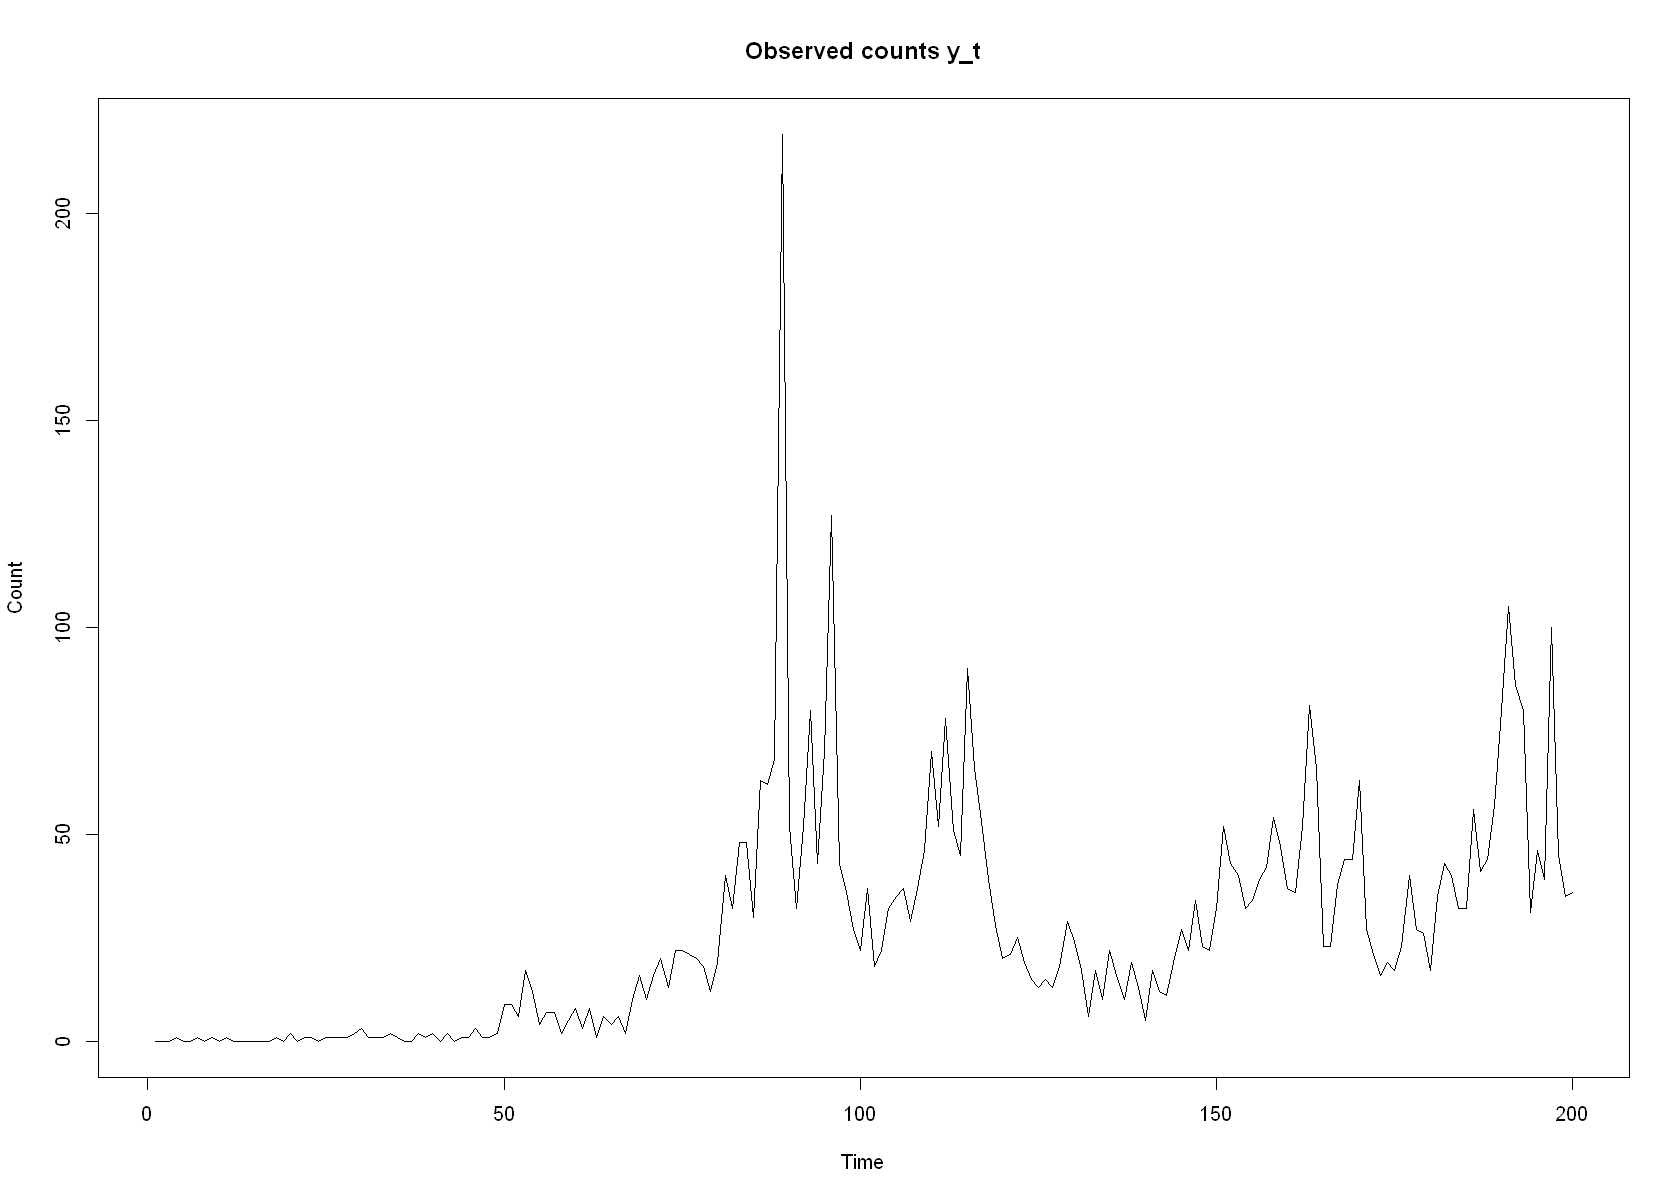

In [56]:
install.packages("RTMB")
library(RTMB)

# Load the data
load(url("https://www.math.ntnu.no/emner/TMA4300/2026v/theta-logistic.RData"))
cat("Number of observations:", length(y), "\n")
par(bg = "white")
plot(y, type = "l", xlab = "Time", ylab = "Count", main = "Observed counts y_t")

In [57]:
# Define the negative log joint density for RTMB
f <- function(parms) {
  getAll(parms, data)
  
  r0 <- exp(logr0)
  theta <- exp(logtheta)
  K <- exp(logK)
  sigma <- exp(logsigma)
  
  y <- OBS(y)
  
  n <- length(u)
  nll <- 0
  
  # State transitions: u_t | u_{t-1} ~ N(mu_t, sigma^2)
  for (t in 2:n) {
    m <- u[t-1] + r0 * (1.0 - (exp(u[t-1]) / K)^theta)
    nll <- nll - dnorm(u[t], m, sigma, log = TRUE)
  }
  
  # Observations: y_t ~ Poisson(exp(u_t))
  for (t in 1:n) {
    nll <- nll - dpois(y[t], lambda = exp(u[t]), log = TRUE)
  }
  
  ADREPORT(r0)
  ADREPORT(K)
  ADREPORT(theta)
  ADREPORT(sigma)
  
  return(nll)
}

# Data and initial parameters
data <- list(y = y)
n <- length(y)

parameters <- list(
  logr0 = log(0.1),
  logtheta = log(1),
  logK = log(mean(y)),
  logsigma = log(0.3),
  u = rep(log(mean(y)), n)
)

# Create objective function with Laplace approximation over u
obj <- MakeADFun(f, parameters, random = "u", silent = TRUE)

### Part c) Maximise the Laplace approximation

We optimise the Laplace-approximated marginal likelihood using `nlminb` and examine the estimated parameters and latent states.

In [58]:
# Maximize the Laplace approximation of the marginal likelihood
opt <- nlminb(obj$par, obj$fn, obj$gr,
              control = list(eval.max = 5000, iter.max = 2000))

cat("Convergence:", opt$convergence, "(0 = success)\n")
cat("Objective:", opt$objective, "\n\n")

# Parameter estimates and standard errors
sdr <- sdreport(obj)
cat("Fixed parameters (log scale):\n")
print(summary(sdr, "fixed"))
cat("\nTransformed parameters (original scale):\n")
print(summary(sdr, "report"))

Convergence: 0 (0 = success)
Objective: 637.1859 

Fixed parameters (log scale):
          Estimate Std. Error
logr0    -2.412901 0.36761597
logtheta  0.631412 0.19133982
logK      3.789689 0.18804185
logsigma -1.102396 0.07890169

Transformed parameters (original scale):
         Estimate Std. Error
r0     0.08955514 0.03292190
K     44.24266014 8.31947168
theta  1.88026370 0.35976932
sigma  0.33207435 0.02620123


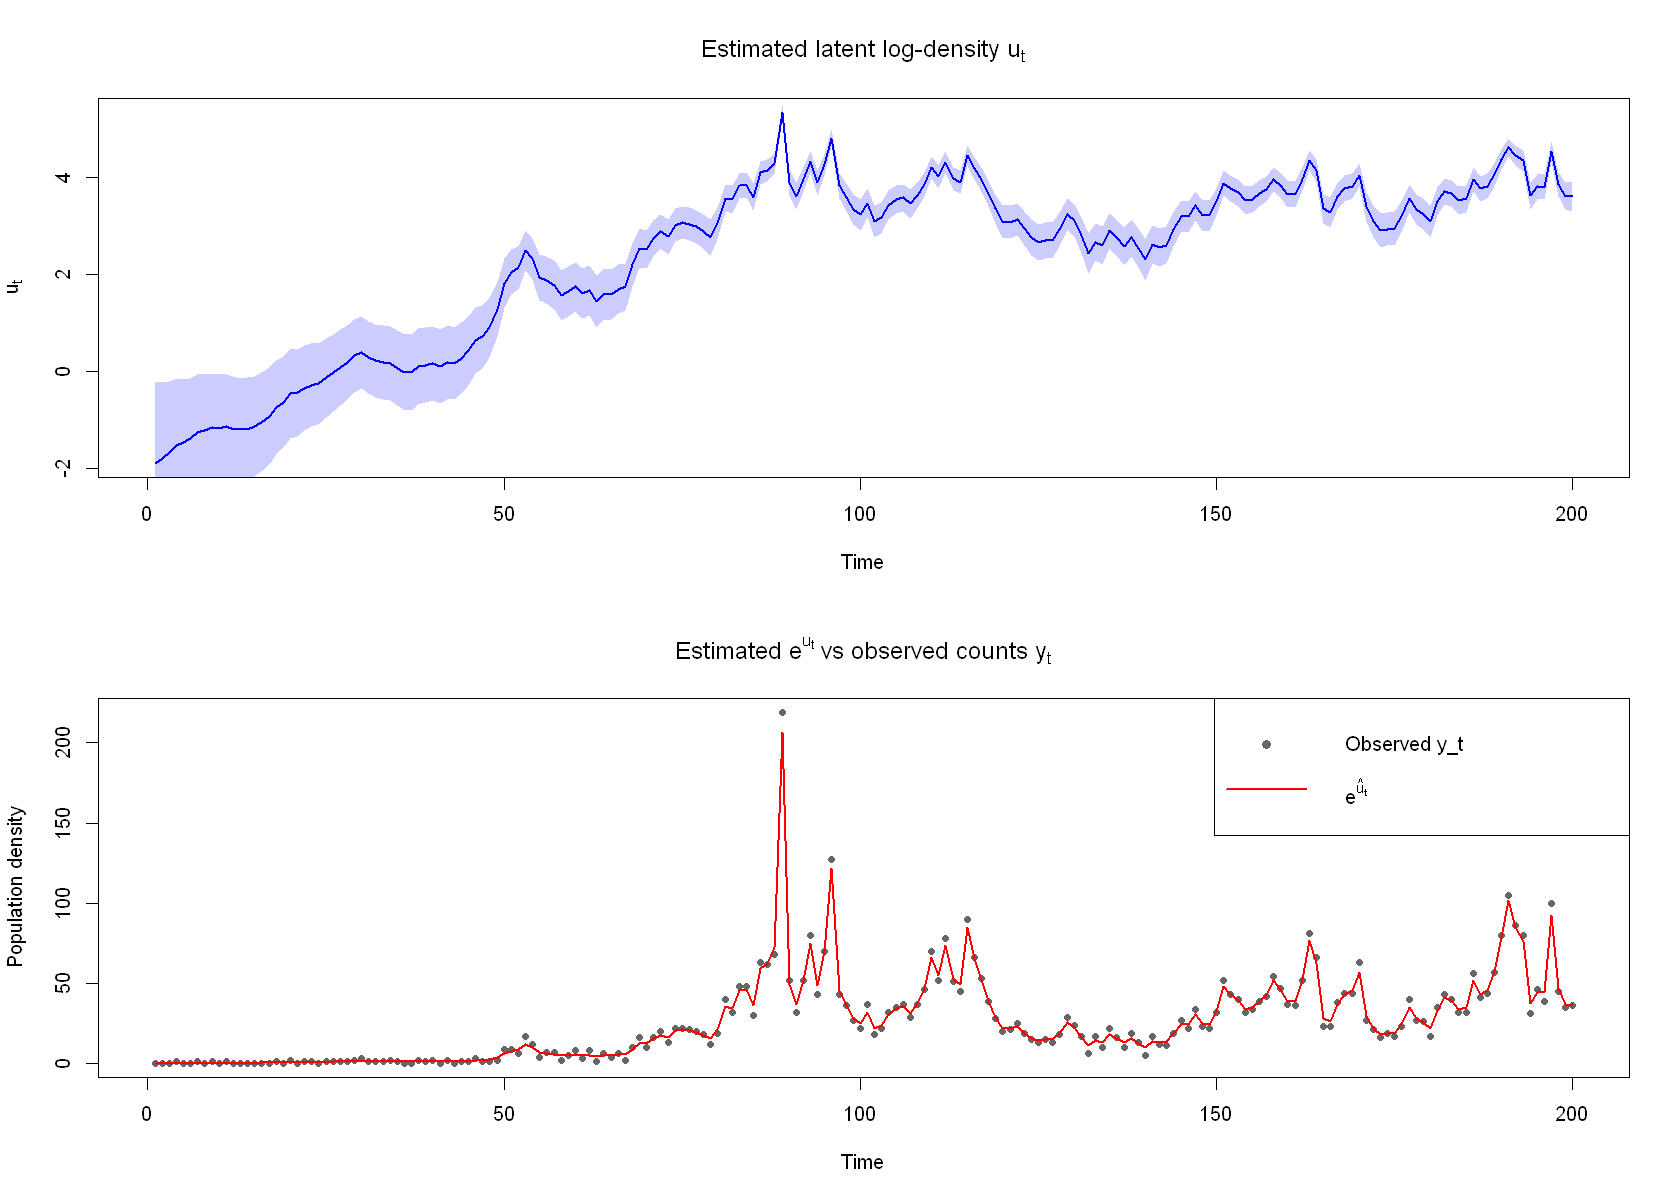

In [59]:
# Extract estimated latent states
u_hat <- summary(sdr, "random")[, "Estimate"]
u_se <- summary(sdr, "random")[, "Std. Error"]

par(bg = "white", mfrow = c(2, 1))
options(repr.plot.width = 14, repr.plot.height = 10)

# Plot u_t estimates with confidence bands
plot(u_hat, type = "l", col = "blue", lwd = 2,
     xlab = "Time", ylab = expression(u[t]),
     main = expression("Estimated latent log-density " * u[t]))
polygon(c(1:n, n:1),
        c(u_hat + 1.96 * u_se, rev(u_hat - 1.96 * u_se)),
        col = rgb(0, 0, 1, 0.2), border = NA)
lines(u_hat, col = "blue", lwd = 2)

# Plot exp(u_t) vs observed counts y_t
plot(y, type = "p", pch = 16, col = "grey40", cex = 0.8,
     xlab = "Time", ylab = "Population density",
     main = expression("Estimated " * e^{u[t]} * " vs observed counts " * y[t]))
lines(exp(u_hat), col = "red", lwd = 2)
legend("topright", legend = c("Observed y_t", expression(e^{hat(u)[t]})),
       col = c("grey40", "red"), pch = c(16, NA), lwd = c(NA, 2))

The optimization converges successfully. The estimated parameters on the original scale are:

| Parameter | Estimate | Std. Error | Interpretation |
|-----------|----------|------------|----------------|
| $r$ | 0.090 | 0.033 | Slow population growth rate at low density |
| $K$ | 44.2 | 8.3 | Carrying capacity consistent with median observed count of 20 |
| $\theta$ | 1.88 | 0.36 | Super-linear density dependence ($\theta > 1$) |
| $\sigma$ | 0.33 | 0.026 | Moderate process noise |

The plots show that the estimated latent trajectory $e^{\hat{u}_t}$ smoothly tracks the observed counts $y_t$. The confidence bands on $u_t$ are narrow in the middle of the time series and wider at the endpoints.

### Part d) Simulation study

We write a function to simulate synthetic data from the theta-logistic model, fit the model to several realisations, and compare estimation errors to the standard errors reported by `sdreport`.

The standard errors from `sdreport` are based on the delta method: for the fixed parameters, they come from the inverse of the Hessian of the Laplace approximated marginal negative log-likelihood at the optimum. For reported (transformed) parameters, the delta method is applied to propagate uncertainty through the transformation. These are asymptotic standard errors based on a normal approximation to the sampling distribution of the MLE.

In [60]:
# Function to simulate from the theta-logistic model
simulate_theta_logistic <- function(n, r0, K, theta, sigma, u1) {
  u <- numeric(n)
  u[1] <- u1
  
  for (t in 2:n) {
    mu_t <- u[t-1] + r0 * (1 - (exp(u[t-1]) / K)^theta)
    u[t] <- rnorm(1, mean = mu_t, sd = sigma)
  }
  
  # Observations with c = 1
  y_sim <- rpois(n, lambda = exp(u))
  
  return(list(y = y_sim, u = u))
}

# Use estimated parameters from the real data as "true" values
true_r0 <- exp(opt$par["logr0"])
true_K <- exp(opt$par["logK"])
true_theta <- exp(opt$par["logtheta"])
true_sigma <- exp(opt$par["logsigma"])

cat("True parameters for simulation:\n")
cat("  r0 =", true_r0, "\n")
cat("  K =", true_K, "\n")
cat("  theta =", true_theta, "\n")
cat("  sigma =", true_sigma, "\n")

True parameters for simulation:
  r0 = 0.08955514 
  K = 44.24266 


  theta = 1.880264 
  sigma = 0.3320743 


In [61]:
# Simulation study: fit model to multiple synthetic datasets
set.seed(123)
n_sim <- 20
n_obs <- length(y)

# True values on log scale
true_fixed <- opt$par

# Define a new function for simulation that takes data as argument
f_sim <- function(parms) {
  getAll(parms, sim_data)
  
  r0 <- exp(logr0)
  theta <- exp(logtheta)
  K <- exp(logK)
  sigma <- exp(logsigma)
  
  y <- OBS(y)
  
  n <- length(u)
  nll <- 0
  
  for (t in 2:n) {
    m <- u[t-1] + r0 * (1.0 - (exp(u[t-1]) / K)^theta)
    nll <- nll - dnorm(u[t], m, sigma, log = TRUE)
  }
  
  for (t in 1:n) {
    nll <- nll - dpois(y[t], lambda = exp(u[t]), log = TRUE)
  }
  
  return(nll)
}

# Storage for estimates and standard errors
est_fixed <- matrix(NA, nrow = n_sim, ncol = 4)
se_fixed <- matrix(NA, nrow = n_sim, ncol = 4)
colnames(est_fixed) <- colnames(se_fixed) <- names(opt$par)

for (s in 1:n_sim) {
  # Simulate data
  sim <- simulate_theta_logistic(n_obs, true_r0, true_K, true_theta, true_sigma, u1 = u_hat[1])
  
  # Set sim_data in the environment where f_sim can see it
  sim_data <- list(y = sim$y)
  
  parms_sim <- list(
    logr0 = log(0.1),
    logtheta = log(1),
    logK = log(mean(sim$y) + 1),
    logsigma = log(0.3),
    u = rep(log(mean(sim$y) + 1), n_obs)
  )
  
  obj_sim <- tryCatch(
    MakeADFun(f_sim, parms_sim, random = "u", silent = TRUE),
    error = function(e) NULL
  )
  if (is.null(obj_sim)) next
  
  opt_sim <- tryCatch(
    nlminb(obj_sim$par, obj_sim$fn, obj_sim$gr,
           control = list(eval.max = 5000, iter.max = 2000)),
    error = function(e) NULL
  )
  if (is.null(opt_sim) || opt_sim$convergence != 0) next
  
  sdr_sim <- tryCatch(sdreport(obj_sim), error = function(e) NULL)
  if (is.null(sdr_sim)) next
  
  fixed_summary <- summary(sdr_sim, "fixed")
  est_fixed[s, ] <- fixed_summary[, "Estimate"]
  se_fixed[s, ] <- fixed_summary[, "Std. Error"]
  
  cat("Simulation", s, "done. Convergence:", opt_sim$convergence, "\n")
}

cat("\nSuccessful fits:", sum(!is.na(est_fixed[, 1])), "out of", n_sim, "\n")

Simulation 1 done. Convergence: 0 
Simulation 2 done. Convergence: 0 
Simulation 3 done. Convergence: 0 
Simulation 4 done. Convergence: 0 
Simulation 5 done. Convergence: 0 
Simulation 6 done. Convergence: 0 
Simulation 7 done. Convergence: 0 
Simulation 8 done. Convergence: 0 
Simulation 9 done. Convergence: 0 
Simulation 10 done. Convergence: 0 


Warning message in sqrt(diag(object$cov.fixed)):
"NaNs produced"


Simulation 11 done. Convergence: 0 
Simulation 12 done. Convergence: 0 
Simulation 13 done. Convergence: 0 
Simulation 14 done. Convergence: 0 
Simulation 15 done. Convergence: 0 
Simulation 16 done. Convergence: 0 
Simulation 17 done. Convergence: 0 
Simulation 18 done. Convergence: 0 
Simulation 19 done. Convergence: 0 
Simulation 20 done. Convergence: 0 

Successful fits: 20 out of 20 


In [62]:
# Compare estimation errors to reported standard errors
valid <- !is.na(est_fixed[, 1])

# Handle NaN in se_fixed for the mean: use na.rm
errors <- sweep(est_fixed[valid, ], 2, true_fixed)
mean_se <- colMeans(se_fixed[valid, ], na.rm = TRUE)
empirical_sd <- apply(errors, 2, sd)

comparison <- data.frame(
  Parameter = names(opt$par),
  True_value = as.numeric(true_fixed),
  Mean_estimate = colMeans(est_fixed[valid, ]),
  Mean_bias = colMeans(errors),
  Empirical_SD = empirical_sd,
  Mean_reported_SE = mean_se,
  Ratio_EmpSD_SE = empirical_sd / mean_se
)
rownames(comparison) <- NULL
print(comparison)

  Parameter True_value Mean_estimate   Mean_bias Empirical_SD Mean_reported_SE
1     logr0  -2.412901    -1.4578526  0.95504820   4.13700238       0.40268136
2  logtheta   0.631412    -0.2743615 -0.90577352   4.34617633       0.38926244
3      logK   3.789689     3.7592706 -0.03041893   0.24529344       0.20552965
4  logsigma  -1.102396    -1.1561867 -0.05379026   0.07581752       0.08312971
  Ratio_EmpSD_SE
1     10.2736377
2     11.1651572
3      1.1934698
4      0.9120388


**Comments on part d) ,  Simulation study:**

All 20 simulations converged. The results are:

- $\log K$ and $\log\sigma$ have `Ratio_EmpSD_SE` close to 1 (1.19 and 0.91 respectively), meaning the standard errors reported by `sdreport` accurately reflect the true variability. The Laplace approximation works well for these parameters.

- $\log r_0$ and $\log\theta$ show much larger empirical variability than the reported standard errors, and one simulation produced NaN standard errors. This reflects a well-known property of the theta-logistic model: $r$ and $\theta$ are poorly identified because they trade off against each other,  many combinations of $(r, \theta)$ produce similar dynamics. The large empirical SD (4.1 and 4.3) confirms this near-non-identifiability.

- Bias is negligible for $\log K$ and $\log\sigma$ ($<0.06$), but substantial for $\log r_0$ and $\log\theta$,  again reflecting their poor identifiability.

Theory behind `sdreport` standard errors: The standard errors are based on the delta method applied to the Laplace-approximated marginal likelihood. For the fixed parameters $\boldsymbol{\theta}$, the covariance matrix is estimated as the inverse of the Hessian of the negative log marginal likelihood at the optimum: $\text{Cov}(\hat{\boldsymbol{\theta}}) \approx \mathcal{H}^{-1}$. For back-transformed parameters reported via `ADREPORT` (e.g., $K = e^{\log K}$), the delta method propagates the uncertainty: $\text{Var}(g(\hat\theta)) \approx g'(\hat\theta)^2 \text{Var}(\hat\theta)$. This is an asymptotic normal approximation that assumes the likelihood is approximately quadratic near the optimum, an assumption that may not hold well for poorly identified parameters like $r$ and $\theta$.